In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
from matplotlib import rc
rc('font',size=18)

In [2]:
from pynitride.devices import gan_pfet
from pynitride.paramdb import nm,cm, k
from pynitride.solvers import PoissonSolver, Equilibrium, SelfConsistentLoop
from pynitride.carriers import Semiclassical, Schrodinger, MultibandKP

# Semiclassical

In [3]:
m,[scm,clm]=gan_pfet(8*nm,200*nm,Ndef=5e16/cm**3)

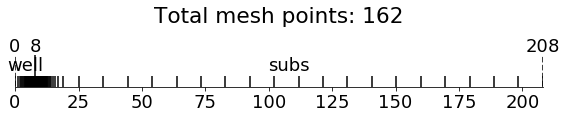

In [4]:
m.plot_mesh()

In [5]:
Equilibrium(m)
scl=SelfConsistentLoop(fieldsolvers=[PoissonSolver(m)],carriersolvers=[Semiclassical(m)])

Using explicit masses from file


In [6]:
scl.ramp_epsfactor(max_iter=20)

Starting eps factor ramp from 10000 to 1
  Eps factor: 1.00e+04
  Starting SC loop
    iter:   0  err: 4.52e-16  activ: 1
    Loop finished in  1 iterations with err=4.51723e-16
  Eps factor: 6.31e+03
  Starting SC loop
    iter:   0  err: 4.04e-04  activ: 1
    iter:   1  err: 1.76e-16  activ: 1
    Loop finished in  2 iterations with err=1.76196e-16
  Eps factor: 2.51e+03
  Starting SC loop
    iter:   0  err: 1.66e-03  activ: 1
    iter:   1  err: 5.62e-16  activ: 1
    Loop finished in  2 iterations with err=5.61613e-16
  Eps factor: 7.94e+02
  Starting SC loop
    iter:   0  err: 5.95e-03  activ: 1
    iter:   1  err: 1.42e-15  activ: 1
    Loop finished in  2 iterations with err=1.42058e-15
  Eps factor: 2.51e+02
  Starting SC loop
    iter:   0  err: 1.88e-02  activ: 1
    iter:   1  err: 7.26e-16  activ: 1
    Loop finished in  2 iterations with err=7.2581e-16
  Eps factor: 7.94e+01
  Starting SC loop
    iter:   0  err: 5.95e-02  activ: 1
    iter:   1  err: 8.91e-15  activ: 1

(0, 20)

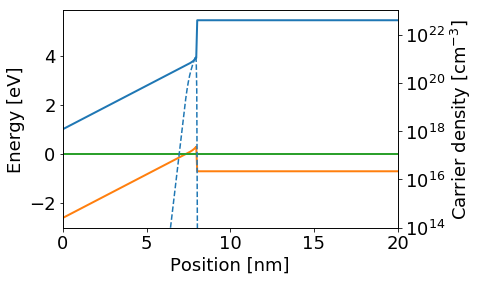

In [7]:
plt.figure()
plt.plot(m.zp,m.Ec,linewidth=2)
plt.plot(m.zp,m.Ev,linewidth=2)
plt.plot(m.zp,m.EF,linewidth=2)
plt.xlabel("Position [nm]")
plt.ylabel("Energy [eV]")

plt.twinx()
plt.plot(m.zp,m.p/(1/cm**3),'--')
plt.plot(m.zp,m.n/(1/cm**3),'--')
plt.yscale('log')
plt.ylabel("Carrier density [cm$^{-3}$]")
plt.ylim(1e14,1e23)

plt.xlim(0,20)

In [8]:
m.p.integrate(definite=True)/(1/cm**2)  /1e13

Function(2.9839175346720683)

# Schrodinger

In [9]:
m,[scm,clm]=gan_pfet(8*nm,200*nm,Ndef=5e16/cm**3,)

In [10]:
Equilibrium(m)

In [11]:
scl=SelfConsistentLoop(fieldsolvers=[PoissonSolver(m)],carriersolvers=[Schrodinger(scm),Semiclassical(clm)])

Using explicit masses from file
WHAT IS THIS BC
Using explicit masses from file


In [12]:
scl.ramp_epsfactor(max_iter=20,dlefmin=.025)

Starting eps factor ramp from 10000 to 1
  Eps factor: 1.00e+04
  Starting SC loop
[ 2.62360988  2.64551472  2.6829537   2.72859277  2.77590167  2.84957173
  2.95137249  3.0772181   3.22647714]
[ 2.65061022  2.71905287  2.83789073  2.99066538  3.1447417   3.36832829
  3.47303841  3.48239256  3.49784219]
[ 2.93859921  2.94505509  2.95608601  2.9693805   2.98330936  3.00532098
  3.03562424  3.07316345  3.11800746]
    iter:   0  err: 4.52e-16  activ: 1
    Loop finished in  1 iterations with err=4.51723e-16
  Eps factor: 6.31e+03
  Starting SC loop
[ 2.62360988  2.64551472  2.6829537   2.72859277  2.77590167  2.84957173
  2.95137249  3.0772181   3.22647714]
[ 2.65061022  2.71905287  2.83789073  2.99066538  3.1447417   3.36832829
  3.47303841  3.48239256  3.49784219]
[ 2.93859921  2.94505509  2.95608601  2.9693805   2.98330936  3.00532098
  3.03562424  3.07316345  3.11800746]
    iter:   0  err: 4.04e-04  activ: 1
[ 2.6234278   2.64532769  2.6827716   2.72845079  2.77573985  2.84936465
  

[-0.0968271  -0.06763438 -0.05564901 -0.04222245 -0.01190489  0.03333989
  0.0931135   0.1635142   0.22339588]
[ 0.05090761  0.0907513   0.10224772  0.11010263  0.1202491   0.12552125
  0.13403244  0.14609515  0.1582065 ]
           iter:   4  err: 3.46e-01
    Retrying with Poisson activation=0.125
[-0.1095716  -0.087752   -0.04573928 -0.03421108 -0.02088226  0.00266197
  0.03241693  0.05128857  0.08519973]
[-0.08879141 -0.0599994  -0.04853417 -0.03612626 -0.00571648  0.03974891
  0.10001404  0.17240387  0.23584679]
[ 0.05942098  0.09621885  0.10946209  0.11660453  0.12582486  0.13121314
  0.13983707  0.15197871  0.1643823 ]
           iter:   4  err: 3.61e-01
    Retrying with Poisson activation=0.0625
  Failure: Couldn't reduce error in SC loop
  Restoring at 2.51e+00
[ 0.21332298  0.55599849  0.73511195  0.73987843  0.7476761   0.76152025
  0.78187832  0.80683625  0.83157167]
[ 0.33118716  0.72401421  0.73315414  0.74799782  0.77403137  0.81082704
  0.85099098  0.89688195  0.966624

[ 0.41924037  0.64898858  0.83327614  0.89653439  0.89767961  0.89957854
  0.90300636  0.90823203  0.91545947]
  Eps factor: 1.88e+00
  Starting SC loop
[-1.27227275 -0.84819709 -0.84451112 -0.83927637 -0.83040617 -0.81561686
 -0.79350569 -0.76302407 -0.7232199 ]
[-1.13392121 -0.85865727 -0.84927325 -0.83369443 -0.80565292 -0.76316279
 -0.70493659 -0.62993272 -0.53896675]
[-1.09620084 -0.7886829  -0.68626813 -0.68512343 -0.6832255  -0.67979792
 -0.67456781 -0.66732407 -0.65782291]
    iter:   0  err: 8.38e-01  activ: 1
[-0.49361993 -0.27924187 -0.24972681 -0.24065885 -0.22565309 -0.2063417
 -0.1860156  -0.15987284 -0.12295216]
[-0.39730055 -0.28641721 -0.25677656 -0.24038478 -0.20926801 -0.16465762
 -0.1054224  -0.0319448   0.05184981]
[-0.29243537 -0.12189815 -0.09665387 -0.08404721 -0.08114846 -0.07585303
 -0.06881781 -0.06085228 -0.05325358]
    iter:   1  err: 2.99e-01  activ: 1
[-0.22078238 -0.09036514 -0.08001237 -0.07277337 -0.05715368 -0.03409314
 -0.00465998  0.02491303  0.051

[ 0.24470669  0.48522184  0.67625992  0.71214697  0.71329971  0.71521857
  0.71868459  0.7239643   0.73126428]
    iter:   3  err: 2.34e-02  activ: 1
[ 0.06512636  0.42048504  0.57410466  0.57890897  0.58682123  0.60098207
  0.62223877  0.65050342  0.68295732]
[ 0.1855472   0.5630168   0.57221709  0.58725836  0.6139465   0.65314293
  0.70098632  0.74840809  0.81151473]
[ 0.26723178  0.50644838  0.69664987  0.73551082  0.73666247  0.73857841
  0.74203918  0.74731211  0.75460403]
    iter:   4  err: 1.12e-02  activ: 1
[ 0.07582255  0.43034234  0.58526812  0.59007073  0.59797802  0.61212625
  0.63335209  0.66151749  0.6935999 ]
[ 0.1960609   0.57417983  0.58337745  0.59841013  0.62507146  0.6641771
  0.71166739  0.75875675  0.8222577 ]
[ 0.27812977  0.51680995  0.70660687  0.74667494  0.74782617  0.74974101
  0.75319975  0.75847     0.76575864]
    iter:   5  err: 1.96e-03  activ: 1
[ 0.07769847  0.43206867  0.58722634  0.59202865  0.59993505  0.61408101
  0.63530124  0.66344842  0.695463

[ 0.09881789  0.36647345  0.37585773  0.39132808  0.41916181  0.46122923
  0.51841407  0.59014412  0.66770188]
[ 0.15471637  0.44546842  0.53886642  0.54003912  0.54189045  0.54527283
  0.55046459  0.55766104  0.56709422]
    iter:   2  err: 4.86e-03  activ: 1
[-0.02480013  0.36019671  0.37305012  0.3781937   0.38673464  0.40180036
  0.42424386  0.45485333  0.49446168]
[ 0.09942676  0.36177188  0.37116733  0.38664893  0.4145167   0.45665151
  0.5139808   0.58614249  0.6652784 ]
[ 0.15376232  0.44776852  0.53415927  0.53534049  0.53718758  0.54057065
  0.54577029  0.55298122  0.56243828]
    iter:   3  err: 2.15e-03  activ: 1
[-0.02473293  0.36057545  0.37104216  0.37621755  0.38479979  0.39987939
  0.42231548  0.45291851  0.49253619]
[ 0.09964418  0.35970788  0.36910872  0.38459435  0.41247621  0.45463954
  0.51202938  0.58436849  0.6641657 ]
[ 0.15326879  0.44874215  0.53209243  0.53327844  0.53512284  0.53850546
  0.5437081   0.55092482  0.56039133]
    iter:   4  err: 9.48e-04  acti

(0, 20)

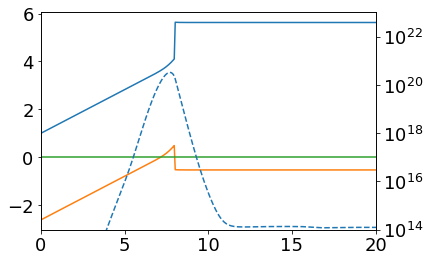

In [13]:
plt.figure()
plt.plot(m.zp,m.Ec)
plt.plot(m.zp,m.Ev)
plt.plot(m.zp,m.EF)

plt.twinx()
plt.plot(m.zp,m.p/(1/cm**3),'--')
plt.plot(m.zp,m.n/(1/cm**3),'--')
plt.yscale('log')
plt.ylim(1e14,1e23)
plt.xlim(0,20)

(5, 11.9)

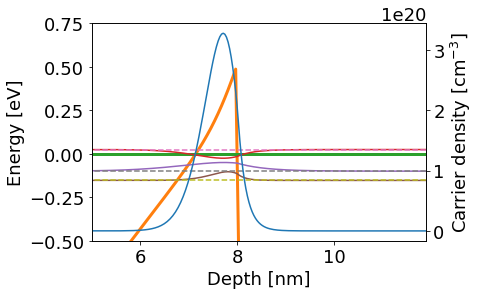

In [38]:
plt.figure()
plt.plot(m.zp,m.Ec,linewidth=3)
plt.plot(m.zp,m.Ev,linewidth=3)
plt.plot(m.zp,m.EF,linewidth=3)
plt.plot(scm.zp,sw[:,:1,0])
plt.plot(scm.zp,sw[:,:1,1])
plt.plot(scm.zp,sw[:,:1,2])
plt.plot(scm.zp,scm.hen.T[:,0,:],'--')
plt.ylim(-.5,.75)
plt.ylabel("Energy [eV]")
plt.xlabel("Depth [nm]")

plt.twinx()
plt.plot(m.zp,m.p/(1/cm**3),'-')
#plt.plot(m.zp,m.n/(1/cm**3),'--')
#plt.yscale('lin')
#plt.ylim(1e14,1e23)
plt.ylabel("Carrier density [cm$^{-3}$]")
plt.xlim(5,11.9)

In [14]:
m.p.integrate(definite=True)/(1/cm**2)  /1e13

Function(2.9264562392388207)

# KPSolver

In [34]:
m,[scm,clm]=gan_pfet(8*nm,200*nm,Ndef=5e16/cm**3,)

In [35]:
Equilibrium(m)

In [36]:
m.ztrans

-1

In [5]:
scl=SelfConsistentLoop(fieldsolvers=[PoissonSolver(m)],carriersolvers=[MultibandKP(scm),Semiclassical(scm,'electron'),Semiclassical(clm)])

Assembling k.p matrices ...


Exception: ztrans not found in mesh

In [6]:
%%timeit -n 1 -r 1
scl.ramp_epsfactor(start=1e1,max_iter=30)

Starting eps factor ramp from 10 to 1
  Eps factor: 1.00e+01
  Starting SC loop
    iter:   0  err: 3.81e-13  activ: 1
    Loop finished in  1 iterations with err=3.81377e-13
  Eps factor: 6.31e+00
  Starting SC loop
    iter:   0  err: 5.05e-01  activ: 1
    iter:   1  err: 7.55e-14  activ: 1
    Loop finished in  2 iterations with err=7.54671e-14
  Eps factor: 2.51e+00
  Starting SC loop
    iter:   0  err: 2.07e+00  activ: 1
    iter:   1  err: 5.47e-01  activ: 1
    iter:   2  err: 2.21e-01  activ: 1
    iter:   3  err: 7.03e-02  activ: 1
    iter:   4  err: 7.20e-02  activ: 1
    Retrying with Poisson activation=0.5
           iter:   4  err: 7.55e-02
    Retrying with Poisson activation=0.25
           iter:   4  err: 7.71e-02
    Retrying with Poisson activation=0.125
           iter:   4  err: 7.79e-02
    Retrying with Poisson activation=0.0625
  Failure: Couldn't reduce error in SC loop
  Restoring at 6.31e+00
  Eps factor: 3.98e+00
  Starting SC loop
    iter:   0  err: 4.69

(0, 20)

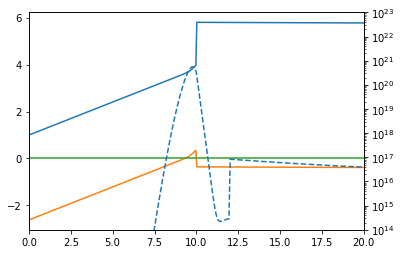

In [7]:
plt.figure()
plt.plot(m.zp,m.Ec)
plt.plot(m.zp,m.Ev)
plt.plot(m.zp,m.EF)

plt.twinx()
plt.plot(m.zp,m.p/(1/cm**3),'--')
#plt.plot(m.zp,m.pderiv*k*m.T.tpf()/(1/cm**3),'.--')
plt.plot(m.zp,m.n/(1/cm**3),'--')
plt.yscale('log')
plt.ylim(1e14,1e23)
plt.xlim(0,20)

In [ ]:
plt.figure()
plt.plot(m.zp,m.Ec)
plt.plot(m.zp,m.Ev)
plt.plot(m.zp,m.EF)

plt.plot

#plt.twinx()
#plt.plot(m.zp,m.p/(1/cm**3),'--')
#plt.plot(m.zp,m.n/(1/cm**3),'--')
#plt.yscale('log')
#plt.ylim(1e14,1e23)
#plt.xlim(0,20)

In [24]:
m.p.integrate(definite=True)/(1/cm**2)  /1e13

Function(3.414648592697289)

# Schro then KPSolver

In [39]:
from pynitride.visual import log
import numpy as np
log._depth=0
log._showlevel=np.inf

In [40]:
m,[scm,clm]=gan_pfet(8*nm,200*nm,Ndef=5e16/cm**3,)

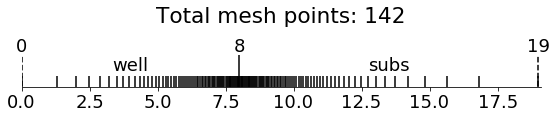

In [41]:
scm.plot_mesh()

In [42]:
Equilibrium(m)

In [64]:
#%%timeit -n 1 -r 1
scl=SelfConsistentLoop(fieldsolvers=[PoissonSolver(m)],carriersolvers=[Schrodinger(scm,'hole'),Semiclassical(scm,'electron'),Semiclassical(clm)])
scl.ramp_epsfactor(start=1e3,max_iter=20,dlefmin=.025)
#mbkp=MultibandKP(scm)
#for cs in [mbkp,Schrodinger(scm,'electron'),Semiclassical(clm)]:
#    cs.solve()
#print(scl._fs[0].isolve())
#for cs in [mbkp,Schrodinger(scm,'electron'),Semiclassical(clm)]:
#    cs.solve()
#print(scl._fs[0].isolve())
psm=PoissonSolver(m)
psm.solve()
mbkp=MultibandKP(scm)
for H in mbkp._H:
    H[:6,:6]*=2
    H[-6:,-6:]*=2
scl=SelfConsistentLoop(fieldsolvers=[psm],carriersolvers=[mbkp,Semiclassical(scm,'electron'),Semiclassical(clm)])
scl.loop(tol=1e-8)

Starting eps factor ramp from 1000 to 1
  Eps factor: 1.00e+03
  Poisson iSolve
  Starting SC loop
    Using averaged effective mass to parabolically populate schrodinger bands
    Poisson iSolve
    iter:   0  err: 4.10e-03  activ: 1
    Using averaged effective mass to parabolically populate schrodinger bands
    Poisson iSolve
    iter:   1  err: 9.40e-16  activ: 1
    Loop finished in  2 iterations with err=9.40246e-16
  Eps factor: 6.31e+02
  Poisson iSolve
  Starting SC loop
    Using averaged effective mass to parabolically populate schrodinger bands
    Poisson iSolve
    iter:   0  err: 4.04e-03  activ: 1
    Using averaged effective mass to parabolically populate schrodinger bands
    Poisson iSolve
    iter:   1  err: 6.13e-16  activ: 1
    Loop finished in  2 iterations with err=6.13394e-16
  Eps factor: 2.51e+02
  Poisson iSolve
  Starting SC loop
    Using averaged effective mass to parabolically populate schrodinger bands
    Poisson iSolve
    iter:   0  err: 1.66e-02  

    Poisson iSolve
           iter:   3  err: 1.38e-01
    Retrying with Poisson activation=0.0625
  Failure: Couldn't reduce error in SC loop
  Restoring at 2.51e+00
  Using averaged effective mass to parabolically populate schrodinger bands
  Eps factor: 2.18e+00
  Poisson iSolve
  Starting SC loop
    Using averaged effective mass to parabolically populate schrodinger bands
    Poisson iSolve
    iter:   0  err: 3.92e-01  activ: 1
    Using averaged effective mass to parabolically populate schrodinger bands
    Poisson iSolve
    iter:   1  err: 1.47e-01  activ: 1
    Using averaged effective mass to parabolically populate schrodinger bands
    Poisson iSolve
    iter:   2  err: 1.50e-01  activ: 1
    Retrying with Poisson activation=0.5
    Using averaged effective mass to parabolically populate schrodinger bands
    Poisson iSolve
           iter:   2  err: 1.53e-01
    Retrying with Poisson activation=0.25
    Using averaged effective mass to parabolically populate schrodinger ba

  not blending
  Poisson iSolve
  iter:   8  err: 2.25e-03  activ: 0.895795
  MBKP Solve
  not blending
  Poisson iSolve
  iter:   9  err: 2.91e-04  activ: 1
  MBKP Solve
  not blending
  Poisson iSolve
  iter:  10  err: 2.18e-05  activ: 1
  MBKP Solve
  not blending
  Poisson iSolve
  iter:  11  err: 6.23e-06  activ: 1
  MBKP Solve
  not blending
  Poisson iSolve
  iter:  12  err: 1.82e-06  activ: 1
  MBKP Solve
  not blending
  Poisson iSolve
  iter:  13  err: 5.36e-07  activ: 1
  MBKP Solve
  not blending
  Poisson iSolve
  iter:  14  err: 1.58e-07  activ: 1
  MBKP Solve
  not blending
  Poisson iSolve
  iter:  15  err: 4.69e-08  activ: 1
  MBKP Solve
  not blending
  Poisson iSolve
  iter:  16  err: 1.39e-08  activ: 1
  MBKP Solve
  not blending
  Poisson iSolve
  iter:  17  err: 4.13e-09  activ: 1
  Loop finished in 18 iterations with err=4.12538e-09


(0, 20)

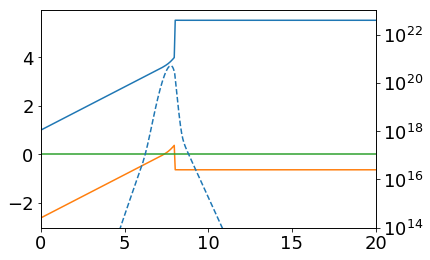

In [65]:
plt.figure()
plt.plot(m.zp,m.Ec)
plt.plot(m.zp,m.Ev)
plt.plot(m.zp,m.EF)

plt.twinx()
plt.plot(m.zp,m.p/(1/cm**3),'--')
#plt.plot(m.zp,m.pderiv*k*m.T.tpf()/(1/cm**3),'.--')
plt.plot(m.zp,m.n/(1/cm**3),'--')
plt.yscale('log')
plt.ylim(1e14,1e23)
plt.xlim(0,20)

(-1.5, 1)

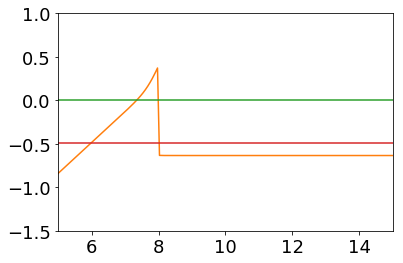

In [82]:
plt.figure()
plt.plot(m.zp,m.Ec)
plt.plot(m.zp,m.Ev)
plt.plot(m.zp,m.EF)

plt.plot(scm.zp,scm.kpen[14,12].T)

#plt.twinx()
#plt.plot(m.zp,m.p/(1/cm**3),'--')
#plt.plot(m.zp,m.n/(1/cm**3),'--')
#plt.yscale('log')
#plt.ylim(1e14,1e23)
plt.xlim(5,15)
plt.ylim(-1.5,1)

In [76]:
mbkp.solve()

MBKP Solve
not blending


In [77]:
np.max(np.abs(mbkp._H[10][:12,:12].todense()-mbkp._H[10][:12,:12].todense().H))

0.0

(-0.8, 0.1)

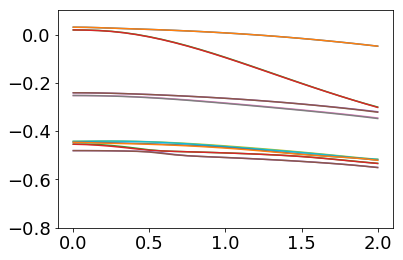

In [78]:
plt.figure()
plt.plot(mbkp._kt,scm.kpen[:,0,0],)
plt.plot(mbkp._kt,scm.kpen[:,1,0],)
plt.plot(mbkp._kt,scm.kpen[:,2,0],)
plt.plot(mbkp._kt,scm.kpen[:,3,0],)
plt.plot(mbkp._kt,scm.kpen[:,4,0],)
plt.plot(mbkp._kt,scm.kpen[:,5,0],)
plt.plot(mbkp._kt,scm.kpen[:,6,0],)
plt.plot(mbkp._kt,scm.kpen[:,7,0],)
plt.plot(mbkp._kt,scm.kpen[:,8,0],)
plt.plot(mbkp._kt,scm.kpen[:,9,0],)
plt.plot(mbkp._kt,scm.kpen[:,10,0],)
plt.plot(mbkp._kt,scm.kpen[:,11,0],)
plt.plot(mbkp._kt,scm.kpen[:,12,0],)
plt.plot(mbkp._kt,scm.kpen[:,13,0],)
plt.plot(mbkp._kt,scm.kpen[:,14,0],)
plt.plot(mbkp._kt,scm.kpen[:,15,0],)

plt.ylim(-.8,.1)

-0.49388306460524517

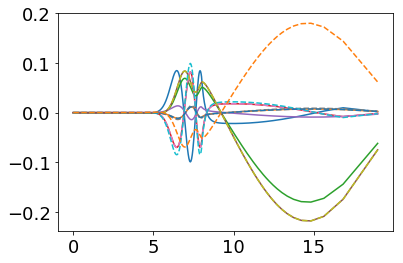

In [79]:
plt.figure()
kti=14
e=12
plt.plot(scm.zp,np.real(scm.kppsi[kti,e,0,:])) #big
plt.plot(scm.zp,np.real(scm.kppsi[kti,e,1,:])) #big
plt.plot(scm.zp,np.real(scm.kppsi[kti,e,2,:])) #nothing
plt.plot(scm.zp,np.real(scm.kppsi[kti,e,3,:])) #smaller
plt.plot(scm.zp,np.real(scm.kppsi[kti,e,4,:])) #smaller
plt.plot(scm.zp,np.real(scm.kppsi[kti,e,5,:])) #nothing
plt.plot(scm.zp,np.imag(scm.kppsi[kti,e,0,:]),'--') #big
plt.plot(scm.zp,np.imag(scm.kppsi[kti,e,1,:]),'--') #big
plt.plot(scm.zp,np.imag(scm.kppsi[kti,e,2,:]),'--') #nothing
plt.plot(scm.zp,np.imag(scm.kppsi[kti,e,3,:]),'--') #smaller
plt.plot(scm.zp,np.imag(scm.kppsi[kti,e,4,:]),'--') #smaller
plt.plot(scm.zp,np.imag(scm.kppsi[kti,e,5,:]),'--') #nothing
scm.kpen[kti,e,100]

In [15]:
from scipy.linalg import eigvalsh

In [16]:
Cmats=m._matsys.kp_Cmats(m,mbkp._kt,0*mbkp._kt)

In [17]:
def E(kz,ikt):
    H=Cmats[ikt][0][:,:,0]+Cmats[ikt][1][:,:,0]*kz+kz*Cmats[ikt][2][:,:,0]+kz*Cmats[ikt][3][:,:,0]*kz
    return eigvalsh(H)

In [23]:
kz=np.linspace(0,2,25)
Ez=[E(kzi,0) for kzi in kz]
Ex=[E(0,ikt) for ikt in range(len(mbkp._kt))]
Exz=[E(kzi,ikt) for kzi,ikt in zip(kz,range(len(mbkp._kt)))]
Exaz=[E(kz[19],ikt) for ikt in range(len(mbkp._kt))]

(-0.2, 0.1)

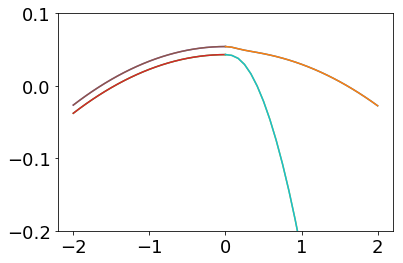

In [24]:
plt.plot(-kz,Ez)
plt.plot(mbkp._kt,Ex)
plt.ylim(-.2,.1)

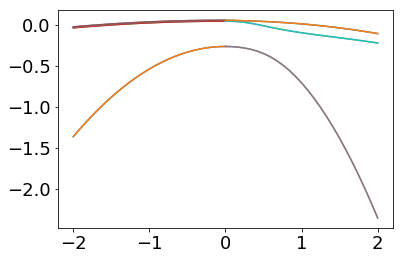

In [25]:
plt.plot(-kz,Ez)
plt.plot(kz,Exz)

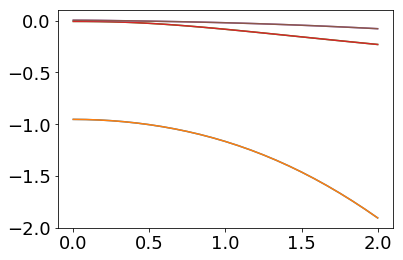

In [30]:
#plt.plot(-kz,Ez)
plt.plot(kz,Exaz)
#plt.ylim(-.1,0)

In [22]:
m.p.integrate(definite=True)/(1/cm**2)  /1e13

Function(4.017983753740012)